<a href="https://colab.research.google.com/github/Arif0000/Pytorch/blob/main/Logistic_using_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
train_dataset = datasets.FashionMNIST(
    root='./dataset',
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.37MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.1MB/s]


In [27]:
test_dataset = datasets.FashionMNIST(
    root='./dataset',
    train=False,
    transform=transforms.ToTensor()
)


In [28]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [29]:
class LogisticRegression(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, num_classes)

    def forward(self, x):
        return self.fc1(x)


In [30]:
model = LogisticRegression(28*28, 10).to(device)

learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [31]:
num_epochs = 10

for epoch in range(num_epochs):

    print('*'*10)
    print(f'Epoch {epoch+1}')

    running_loss = 0
    running_correct = 0
    total = 0

    model.train()

    for i, (img,label) in enumerate(train_loader):

        img = img.view(img.size(0), -1).to(device)
        label = label.to(device)

        outputs = model(img)

        loss = criterion(outputs, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _,pred = torch.max(outputs,1)
        running_correct += (pred == label).sum().item()
        total += label.size(0)

    acc = running_correct / total

    print(f'Loss: {running_loss/len(train_loader):.4f} Accuracy: {acc:.4f}')


**********
Epoch 1
Loss: 1.7054 Accuracy: 0.5613
**********
Epoch 2
Loss: 1.1951 Accuracy: 0.6744
**********
Epoch 3
Loss: 1.0192 Accuracy: 0.6911
**********
Epoch 4
Loss: 0.9271 Accuracy: 0.7106
**********
Epoch 5
Loss: 0.8682 Accuracy: 0.7282
**********
Epoch 6
Loss: 0.8262 Accuracy: 0.7418
**********
Epoch 7
Loss: 0.7940 Accuracy: 0.7518
**********
Epoch 8
Loss: 0.7682 Accuracy: 0.7591
**********
Epoch 9
Loss: 0.7469 Accuracy: 0.7660
**********
Epoch 10
Loss: 0.7289 Accuracy: 0.7716


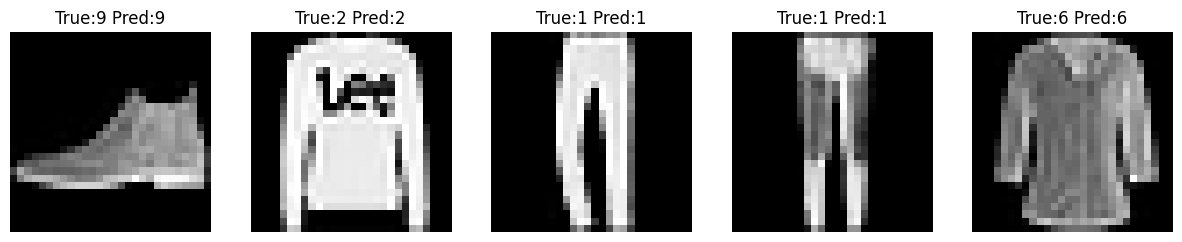

In [32]:
# Testing
images, labels = next(iter(test_loader))

images_flat = images.view(images.size(0), -1).to(device)
labels = labels.to(device)

outputs = model(images_flat)

_,predicted = torch.max(outputs,1)

fig,ax = plt.subplots(1,5,figsize=(15,3))

for i in range(5):

    ax[i].imshow(images[i].reshape(28,28), cmap='gray')
    ax[i].set_title(f'True:{labels[i].item()} Pred:{predicted[i].item()}')
    ax[i].axis('off')

plt.show()